# Catalog EDA

Doing some exploratory data analysis with my newly constructed catalog!

In [1]:
import xarray as xr
import pandas as pd
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
plt.rcParams['text.usetex'] = True

proj_home = Path(os.getcwd()).parents[1]
import sys
sys.path.append(str(proj_home/Path('packages/')))

from display_utils import display_catalog

In [2]:
catalog = pd.read_hdf(proj_home/'project/dataset/datasets/landfalling_df_cleaned.h5')
subcat = catalog[['data_array', 'start_date', 'end_date', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'coarser_region', 'duration', 'max_south_extent', 'cumulative_landfalling_area', 'avg_landfalling_minomega', 'max_landfalling_v850hPa', 'max_vIVT_ais', 'avg_vIVT_ais', 'max_T2M_anomaly_ais', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais']]

In [3]:
catalog.shape

(3101, 28)

## Statistics

In [4]:
covariates = subcat[['max_IWV_ais', 'max_south_extent', 'cumulative_landfalling_area', 'avg_landfalling_minomega', 'max_landfalling_v850hPa', 'max_ocean_SLP_gradient']]

In [5]:
covariates.mean(axis=0)

max_IWV_ais                        10.736989
max_south_extent                  -77.362625
cumulative_landfalling_area    413518.244885
avg_landfalling_minomega           -0.600265
max_landfalling_v850hPa            29.391211
max_ocean_SLP_gradient              5.781443
dtype: object

In [6]:
covariates.std(axis=0)

max_IWV_ais                         3.903743
max_south_extent                    6.064718
cumulative_landfalling_area    696328.942866
avg_landfalling_minomega            0.287546
max_landfalling_v850hPa             6.235371
max_ocean_SLP_gradient              1.784701
dtype: object

## Single Variable Plots

### Covariates

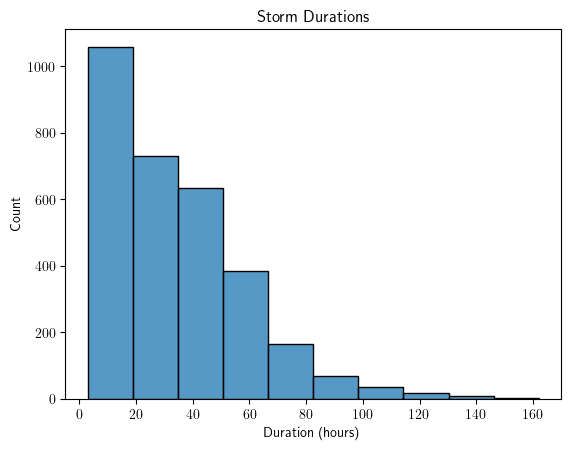

In [7]:
sns.histplot(data = subcat.duration, bins=10);
plt.title('Storm Durations');
plt.xlabel('Duration (hours)');

### The longest storm

In [8]:
display_catalog(subcat.loc[[subcat.duration.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_6,,2022-01-28 09:00:00,2022-02-04 00:00:00,19.773836,3.976208,West,162.000000,-85.000000,3477673.565531,-0.525149,23.783997,380.246948,108.739159,20.211472,0.045131,2.627517


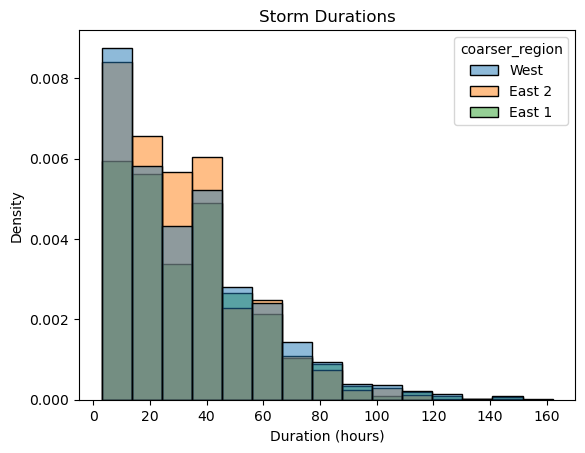

In [25]:
sns.histplot(data = subcat, x='duration', bins=15, hue='coarser_region', stat='density');
plt.title('Storm Durations');
plt.xlabel('Duration (hours)');

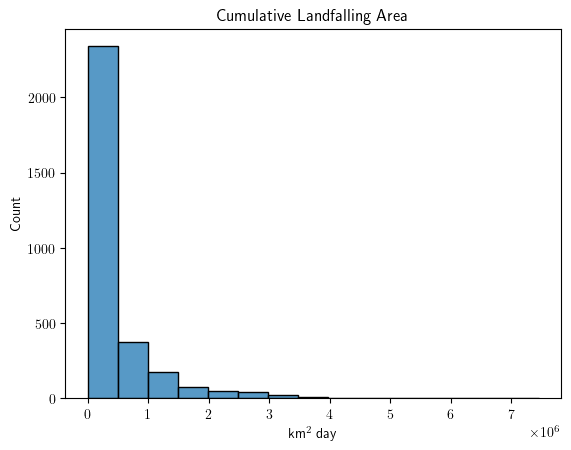

In [81]:
sns.histplot(data=subcat, x='cumulative_landfalling_area', bins=15);
plt.title('Cumulative Landfalling Area');
plt.xlabel('km$^2$ day');

In [38]:
display_catalog(subcat.loc[[subcat.cumulative_landfalling_area.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_12,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7457073.499721,-0.330662,32.607830,482.539856,63.922712,40.972366,0.067925,7.231987


**Fun Fact**: the storm with the greatest cumulative landfalling area was the March 2022 East Antarctic heatwave.

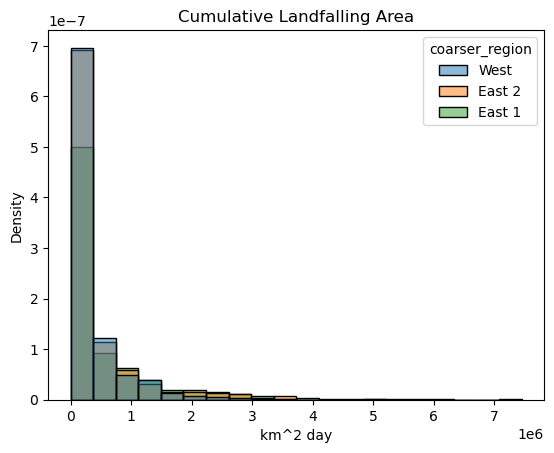

In [28]:
sns.histplot(data=subcat, x='cumulative_landfalling_area', hue='coarser_region', bins=20, stat='density');
plt.title('Cumulative Landfalling Area');
plt.xlabel('km^2 day');

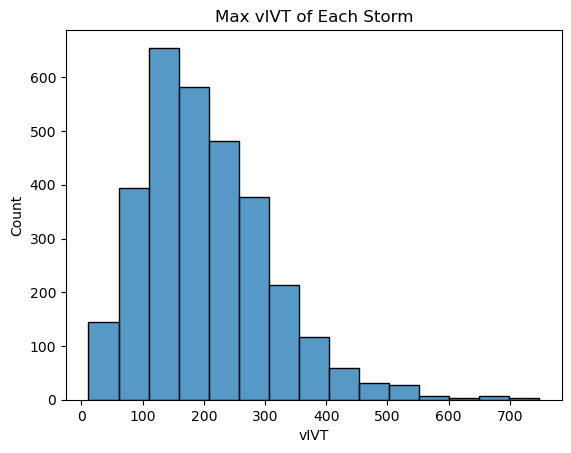

In [29]:
sns.histplot(data=subcat, x='max_vIVT_ais', bins=15);
plt.title('Max vIVT of Each Storm');
plt.xlabel('vIVT');

In [30]:
display_catalog(subcat.loc[[subcat.max_vIVT_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_9,,2022-02-05 12:00:00,2022-02-09 06:00:00,27.609982,4.854247,West,93.000000,-85.000000,2759381.219366,-0.311936,29.558201,748.183411,150.126116,20.089249,0.337306,3.272646


**Fun Fact**: the storm with the greatest landfalling vIVT was the same AR from Gorodetskaya.

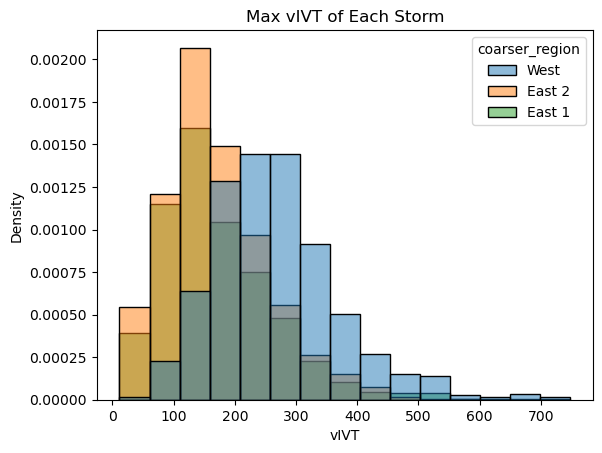

In [31]:
sns.histplot(data=subcat, x='max_vIVT_ais', hue='coarser_region', bins=15, stat='density');
plt.title('Max vIVT of Each Storm');
plt.xlabel('vIVT');

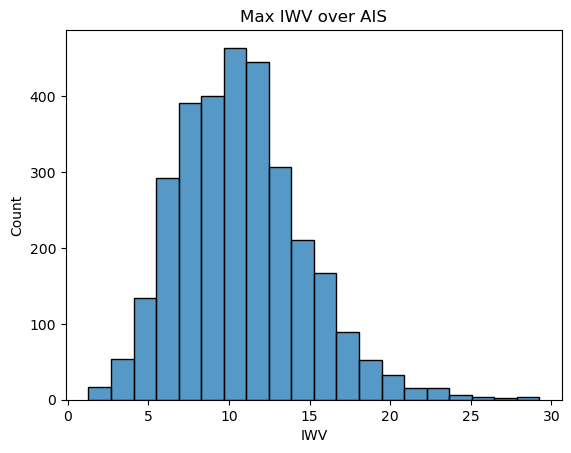

In [32]:
sns.histplot(data=subcat, x='max_IWV_ais', bins=20);
plt.title('Max IWV over AIS');
plt.xlabel('IWV');

In [33]:
display_catalog(subcat.loc[[subcat.max_IWV_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2005_9,,2005-02-08 12:00:00,2005-02-11 12:00:00,29.251392,4.235993,West,75.000000,-85.000000,1568666.399197,-0.780432,26.808243,705.529114,140.250768,17.248505,0.192270,3.073780


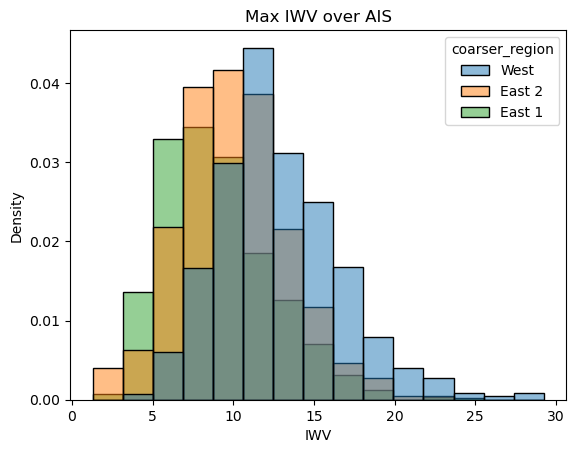

In [34]:
sns.histplot(data=subcat, x='max_IWV_ais', hue='coarser_region', bins=15, stat='density');
plt.title('Max IWV over AIS');
plt.xlabel('IWV');

In [35]:
subcat.columns

Index(['data_array', 'start_date', 'end_date', 'max_IWV_ais',
       'max_ocean_SLP_gradient', 'coarser_region', 'duration',
       'max_south_extent', 'cumulative_landfalling_area',
       'avg_landfalling_minomega', 'max_landfalling_v850hPa', 'max_vIVT_ais',
       'avg_vIVT_ais', 'max_T2M_anomaly_ais', 'cumulative_rainfall_ais',
       'cumulative_snowfall_ais'],
      dtype='object')

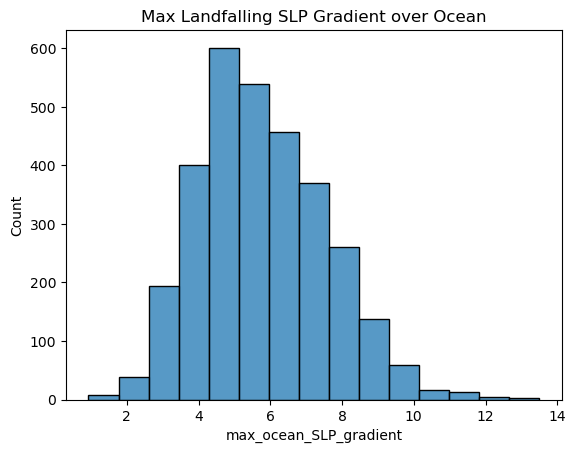

In [36]:
sns.histplot(data=subcat, x='max_ocean_SLP_gradient', bins=15);
plt.title('Max Landfalling SLP Gradient over Ocean');

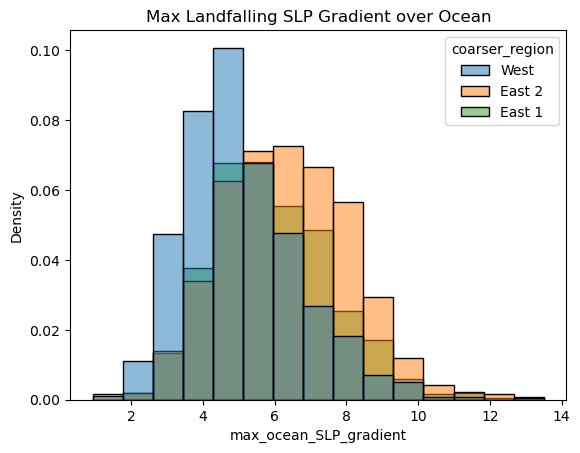

In [37]:
sns.histplot(data=subcat, x='max_ocean_SLP_gradient', hue='coarser_region', bins=15, stat='density');
plt.title('Max Landfalling SLP Gradient over Ocean');

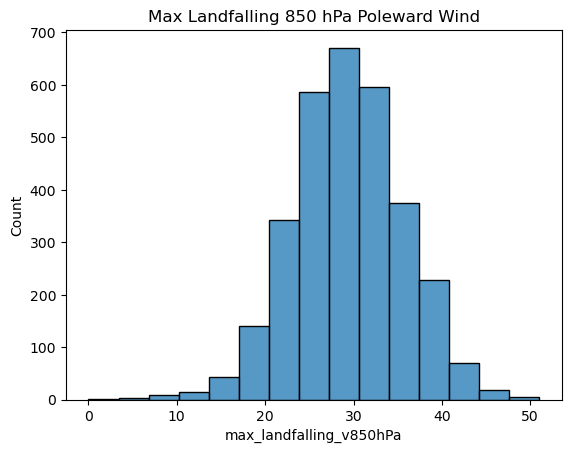

In [38]:
sns.histplot(data=subcat, x='max_landfalling_v850hPa', bins=15);
plt.title('Max Landfalling 850 hPa Poleward Wind');

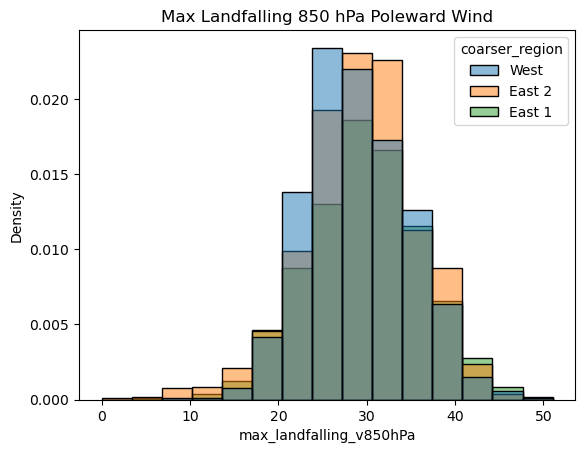

In [39]:
sns.histplot(data=subcat, x='max_landfalling_v850hPa', hue='coarser_region', bins=15, stat='density');
plt.title('Max Landfalling 850 hPa Poleward Wind');

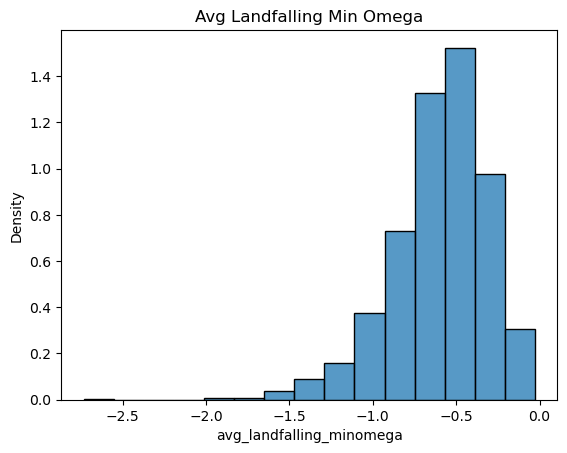

In [41]:
sns.histplot(data=subcat, x='avg_landfalling_minomega', bins=15, stat='density');
plt.title('Avg Landfalling Min Omega');

In [42]:
display_catalog(subcat.loc[[subcat.avg_landfalling_minomega.idxmin()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2000_22,,2000-05-24 21:00:00,2000-05-25 00:00:00,4.911862,6.876014,East 1,6.000000,-66.500000,389.027163,-2.733001,21.940149,62.930138,58.156206,6.745468,0.000000,0.003462


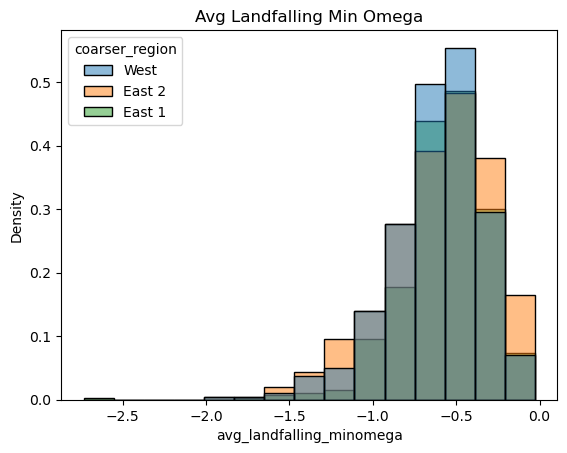

In [40]:
sns.histplot(data=subcat, x='avg_landfalling_minomega', hue='coarser_region', bins=15, stat='density');
plt.title('Avg Landfalling Min Omega');

### Impact/Outcome Variables

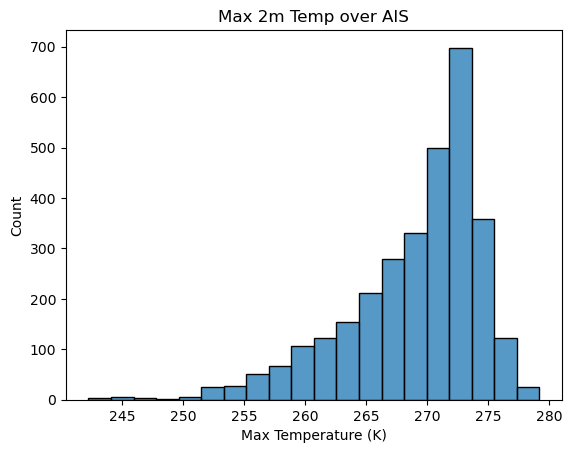

In [90]:
sns.histplot(data=catalog, x='max_T2m_ais', bins=20);
plt.title('Max 2m Temp over AIS');
plt.xlabel('Max Temperature (K)');

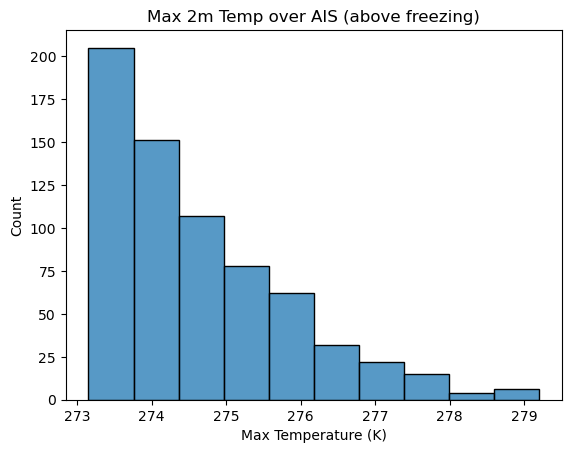

In [91]:
above_freezing = catalog.loc[catalog.max_T2m_ais >= 273.15]
sns.histplot(x=above_freezing.max_T2m_ais, bins=10);
plt.title('Max 2m Temp over AIS (above freezing)');
plt.xlabel('Max Temperature (K)');

**Fun Fact**: the storm with the highest landfalling temperature on the AIS was an AR that caused the Larsen A ice shelf collapse!

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
1995_3,,1995-01-24 00:00:00,1995-01-25 00:00:00,25.030884,6.684744,West,27.000000,-76.500000,118655.727534,-0.547162,35.177967,626.006409,263.376383,9.236847,0.103773,0.519593

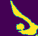

In [92]:
display_catalog(subcat.loc[[catalog.max_T2m_ais.idxmax()]])

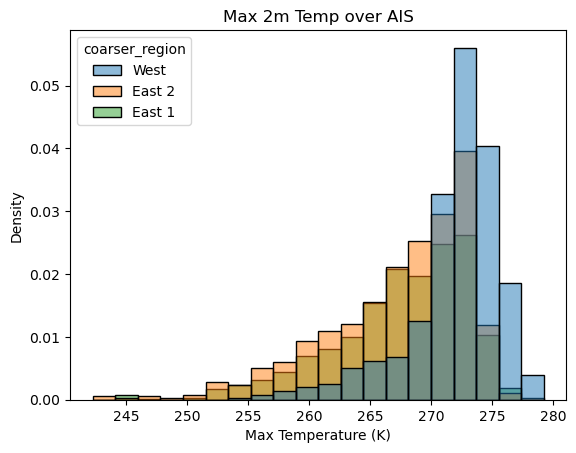

In [93]:
sns.histplot(data=catalog, x='max_T2m_ais', hue='coarser_region', bins=20, stat='density');
plt.title('Max 2m Temp over AIS');
plt.xlabel('Max Temperature (K)');

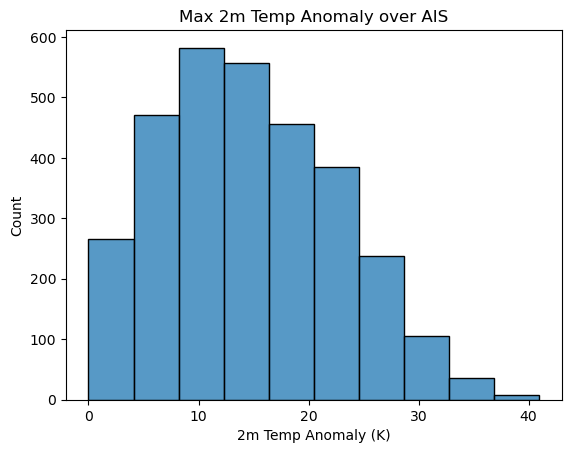

In [94]:
sns.histplot(data=subcat, x='max_T2M_anomaly_ais', bins=10);
plt.title('Max 2m Temp Anomaly over AIS');
plt.xlabel('2m Temp Anomaly (K)');

**Fun Fact**: the storm with the highest max temp anomaly over the ice sheet was the Antarctic AR!

In [95]:
display_catalog(subcat.loc[[subcat.max_T2M_anomaly_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_12,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7457073.499721,-0.330662,32.607830,482.539856,63.922712,40.972366,0.067925,7.231987


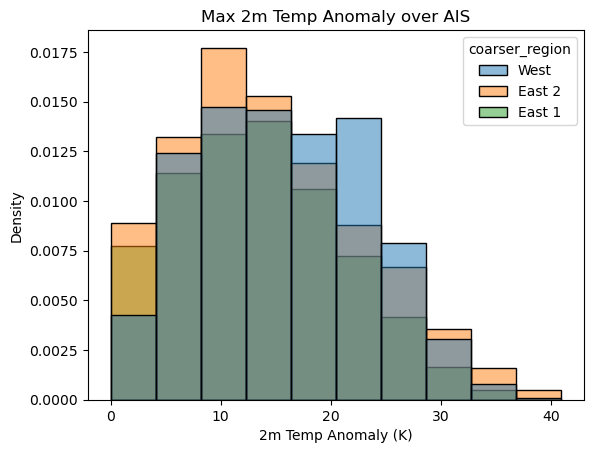

In [96]:
sns.histplot(data=subcat, x='max_T2M_anomaly_ais', hue='coarser_region', stat='density', bins=10);
plt.title('Max 2m Temp Anomaly over AIS');
plt.xlabel('2m Temp Anomaly (K)');

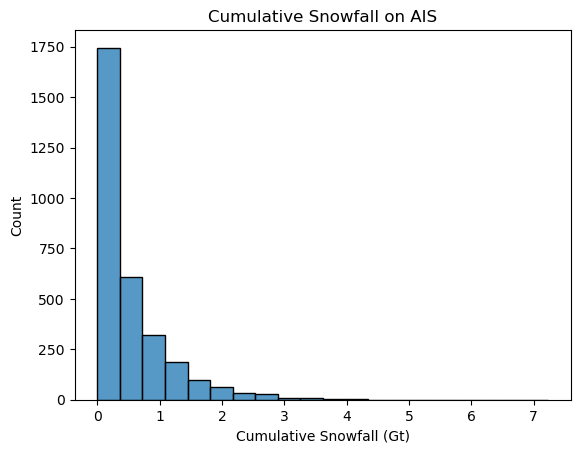

In [97]:
sns.histplot(data=subcat, x='cumulative_snowfall_ais', bins=20);
plt.title('Cumulative Snowfall on AIS');
plt.xlabel('Cumulative Snowfall (Gt)');

**Fun Fact**: the storm that dumped the most snowfall on record of any AR in the catalog was the one that caused the 2022 heat wave.

In [37]:
display_catalog(subcat.loc[[subcat.cumulative_snowfall_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_12,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7457073.499721,-0.330662,32.607830,482.539856,63.922712,40.972366,0.067925,7.231987


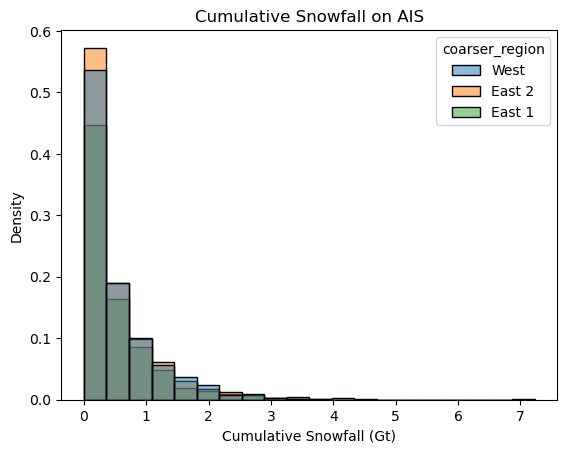

In [99]:
sns.histplot(data=subcat, x='cumulative_snowfall_ais', hue='coarser_region', bins=20, stat='density');
plt.title('Cumulative Snowfall on AIS');
plt.xlabel('Cumulative Snowfall (Gt)');

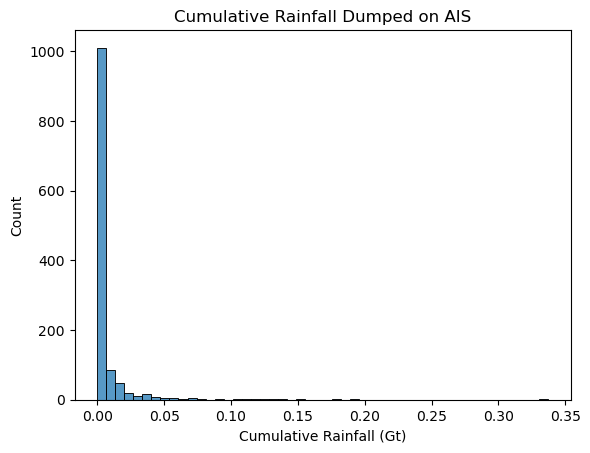

In [100]:
sns.histplot(data=subcat.loc[subcat.cumulative_rainfall_ais > 0], x='cumulative_rainfall_ais', bins=50);
plt.title('Cumulative Rainfall Dumped on AIS');
plt.xlabel('Cumulative Rainfall (Gt)');

**Fun Fact**: storm that dumped the most rain on record (almost twice the amount of rain as the next biggest storm) is an AR from February 2022, studied in Gorodestskaya et al. (2023) (*Record-high Antarctic Peninsula temperatures and surface melt in February 2022: a compound event with an intense atmospheric river*)

In [101]:
display_catalog(subcat.loc[[subcat.cumulative_rainfall_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,avg_landfalling_minomega,max_landfalling_v850hPa,max_vIVT_ais,avg_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
Label,,,,,,,,,,,,,,,,
2022_9,,2022-02-05 12:00:00,2022-02-09 06:00:00,27.609982,4.854247,West,93.000000,-85.000000,2759381.219366,-0.311936,29.558201,748.183411,150.126116,20.089249,0.337306,3.272646


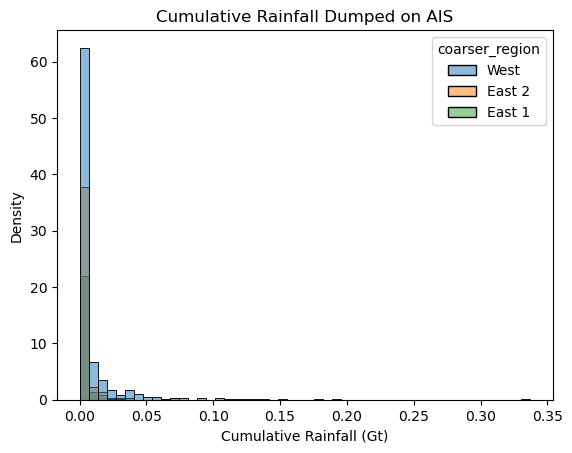

In [102]:
sns.histplot(data=subcat.loc[subcat.cumulative_rainfall_ais > 0], x='cumulative_rainfall_ais', hue='coarser_region', bins=50,  stat='density');
plt.title('Cumulative Rainfall Dumped on AIS');
plt.xlabel('Cumulative Rainfall (Gt)');

Among all ARs, every AR dumped some snow. Among those ARs, about 40% of them also dumped rain.

In [103]:
data_crosstab = pd.crosstab(subcat.cumulative_rainfall_ais > 0, 
                            subcat.cumulative_snowfall_ais > 0,  
                               margins = False, normalize='all') 
data_crosstab

cumulative_snowfall_ais,True
cumulative_rainfall_ais,
False,0.604321
True,0.395679


In [91]:
covariates.columns

Index(['max_IWV_ais', 'max_south_extent', 'cumulative_landfalling_area',
       'avg_landfalling_minomega', 'max_landfalling_v850hPa',
       'max_ocean_SLP_gradient'],
      dtype='object')

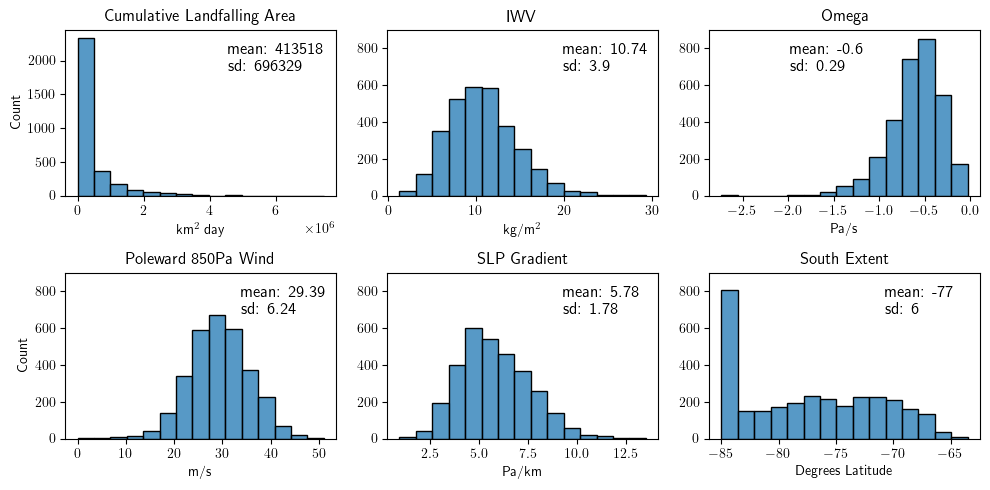

In [9]:
# organizing into a single figure
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(10, 5))

sns.histplot(data=covariates, x='cumulative_landfalling_area', bins=15, ax=axs[0,0])
axs[0,0].set_title('Cumulative Landfalling Area')
axs[0,0].set_xlabel('km$^2$ day')
mean = round(covariates.cumulative_landfalling_area.mean())
sd = round(covariates.cumulative_landfalling_area.std())
axs[0,0].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.60, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='max_IWV_ais', bins=15, ax=axs[0,1])
axs[0,1].set_title('IWV')
axs[0,1].set_xlabel('kg/m$^{2}$')
axs[0,1].set_ylim(0,900)
axs[0,1].set_ylabel('')
mean = round(covariates.max_IWV_ais.mean(),2)
sd = round(covariates.max_IWV_ais.std(),2)
axs[0,1].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='avg_landfalling_minomega', bins=15, ax=axs[0,2])
axs[0,2].set_title('Omega')
axs[0,2].set_xlabel('Pa/s')
axs[0,2].set_ylim(0,900)
axs[0,2].set_ylabel('')
mean = round(covariates.avg_landfalling_minomega.mean(),2)
sd = round(covariates.avg_landfalling_minomega.std(),2)
axs[0,2].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.3, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='max_landfalling_v850hPa', bins=15, ax=axs[1,0])
axs[1,0].set_title('Poleward 850Pa Wind')
axs[1,0].set_xlabel('m/s')
axs[1,0].set_ylim(0,900)
mean = round(covariates.max_landfalling_v850hPa.mean(),2)
sd = round(covariates.max_landfalling_v850hPa.std(),2)
axs[1,0].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='max_ocean_SLP_gradient', bins=15, ax=axs[1,1])
axs[1,1].set_title('SLP Gradient')
axs[1,1].set_xlabel('Pa/km')
axs[1,1].set_ylim(0,900)
axs[1,1].set_ylabel('')
mean = round(covariates.max_ocean_SLP_gradient.mean(),2)
sd = round(covariates.max_ocean_SLP_gradient.std(),2)
axs[1,1].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='max_south_extent', bins=15, ax=axs[1,2])
axs[1,2].set_title('South Extent')
axs[1,2].set_xlabel('Degrees Latitude')
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(0,900)
mean = round(covariates.max_south_extent.mean())
sd = round(covariates.max_south_extent.std())
axs[1,2].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

plt.tight_layout()
plt.savefig('plots/univariate_flavors.png')

In [11]:
impacts = subcat[['cumulative_snowfall_ais', 'max_T2M_anomaly_ais']]

In [5]:
impacts.cumulative_snowfall_ais.mean()

np.float64(0.5060213927849956)

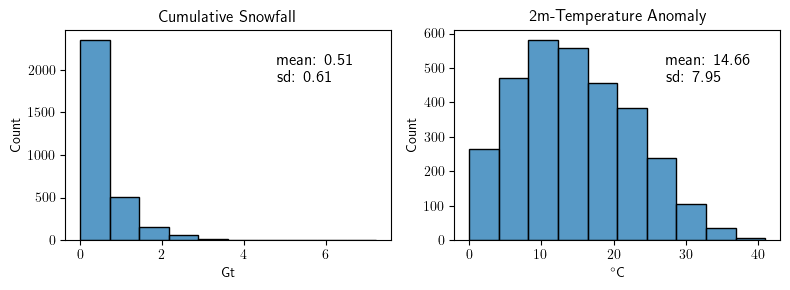

In [6]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
sns.histplot(data=impacts, x='cumulative_snowfall_ais', bins=10, ax=axs[0])
axs[0].set_title('Cumulative Snowfall')
axs[0].set_xlabel('Gt')
mean = round(impacts.cumulative_snowfall_ais.mean(), 2)
sd = round(impacts.cumulative_snowfall_ais.std(), 2)
axs[0].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12)
sns.histplot(data=impacts, x='max_T2M_anomaly_ais', bins=10, ax=axs[1])
axs[1].set_title('2m-Temperature Anomaly')
axs[1].set_xlabel('$^\\circ$C')
mean = round(impacts.max_T2M_anomaly_ais.mean(), 2)
sd = round(impacts.max_T2M_anomaly_ais.std(), 2)
axs[1].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);
plt.tight_layout()
plt.savefig('plots/impact_distributions.png')

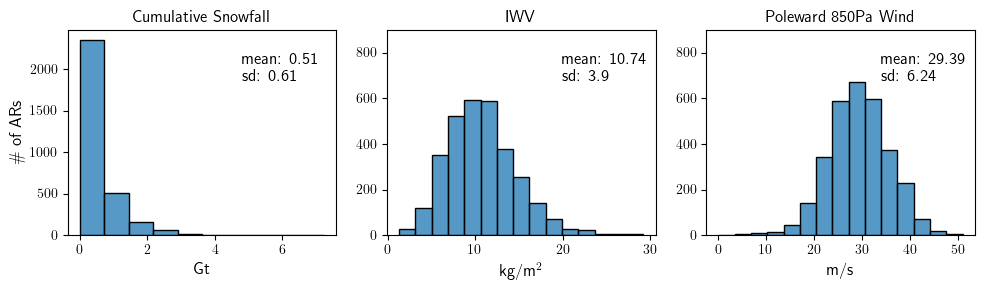

In [21]:
# plots for AGU25

fontsize=12

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
sns.histplot(data=impacts, x='cumulative_snowfall_ais', bins=10, ax=axs[0])
axs[0].set_title('Cumulative Snowfall', fontsize=fontsize)
axs[0].set_xlabel('Gt', fontsize=fontsize)
axs[0].set_ylabel('\\# of ARs', fontsize=fontsize)
mean = round(impacts.cumulative_snowfall_ais.mean(), 2)
sd = round(impacts.cumulative_snowfall_ais.std(), 2)
axs[0].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12)

sns.histplot(data=covariates, x='max_IWV_ais', bins=15, ax=axs[1])
axs[1].set_title('IWV')
axs[1].set_xlabel('kg/m$^{2}$', fontsize=fontsize)
axs[1].set_ylim(0,900)
axs[1].set_ylabel('')
mean = round(covariates.max_IWV_ais.mean(),2)
sd = round(covariates.max_IWV_ais.std(),2)
axs[1].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

sns.histplot(data=covariates, x='max_landfalling_v850hPa', bins=15, ax=axs[2])
axs[2].set_title('Poleward 850Pa Wind', fontsize=fontsize)
axs[2].set_xlabel('m/s', fontsize=fontsize)
axs[2].set_ylim(0,900)
axs[2].set_ylabel('')
mean = round(covariates.max_landfalling_v850hPa.mean(),2)
sd = round(covariates.max_landfalling_v850hPa.std(),2)
axs[2].annotate(text=f'mean: {mean} \n sd: {sd}', xy=(0.65, 0.75), xycoords='axes fraction', fontsize=12);

plt.tight_layout()
plt.savefig('plots/AGU_histograms.png', dpi=300)

## Time Trend Plots

In [36]:
subsubcat = subcat.drop(columns=['data_array', 'end_date'])
subsubcat['year'] = subsubcat.start_date.dt.year
averages = subsubcat.groupby(['year', 'coarser_region'])[['cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_T2M_anomaly_ais', 'max_vIVT_ais', 'duration']].mean()
averages = averages.reset_index()


<Axes: xlabel='year', ylabel='max_IWV_ais'>

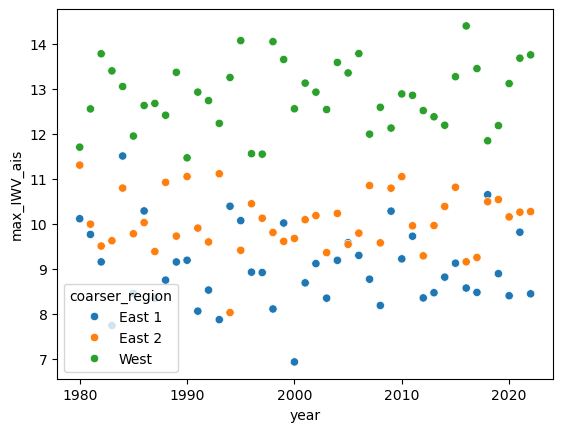

In [37]:
sns.scatterplot(data=averages, x='year', y='max_IWV_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_ocean_SLP_gradient'>

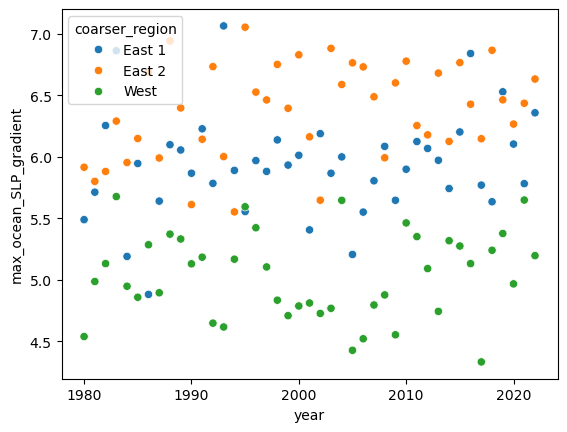

In [38]:
sns.scatterplot(data=averages, x='year', y='max_ocean_SLP_gradient', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_landfalling_v850hPa'>

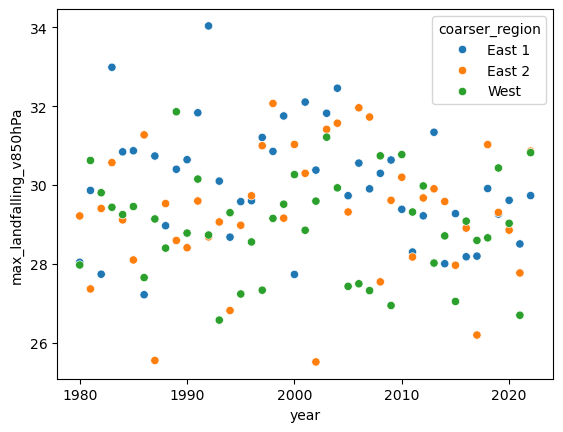

In [39]:
sns.scatterplot(data=averages, x='year', y='max_landfalling_v850hPa', hue='coarser_region')

<Axes: xlabel='year', ylabel='duration'>

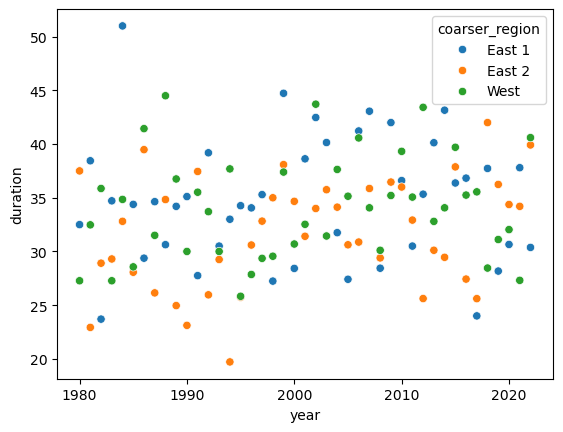

In [40]:
sns.scatterplot(data=averages, x='year', y='duration', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_T2M_anomaly_ais'>

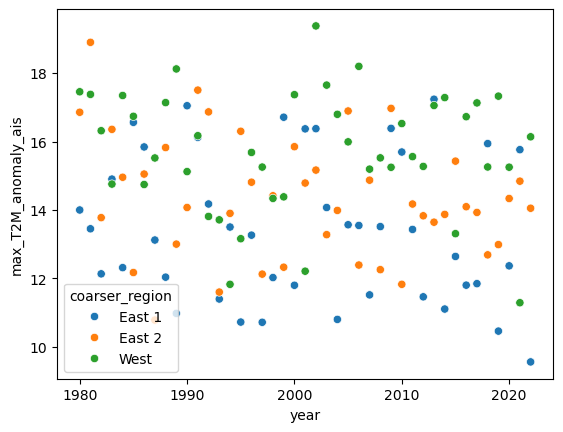

In [41]:
sns.scatterplot(data=averages, x='year', y='max_T2M_anomaly_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='cumulative_rainfall_ais'>

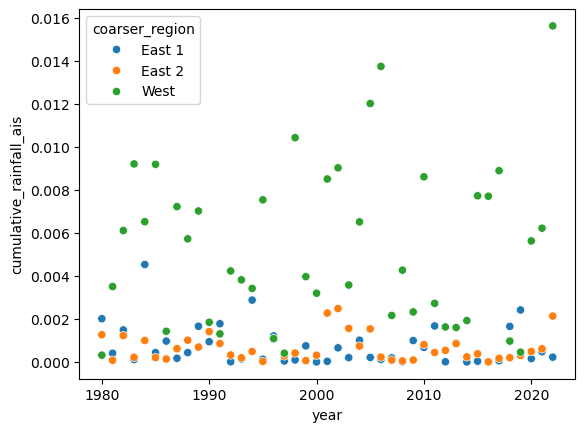

In [42]:
sns.scatterplot(data=averages, x='year', y='cumulative_rainfall_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='cumulative_snowfall_ais'>

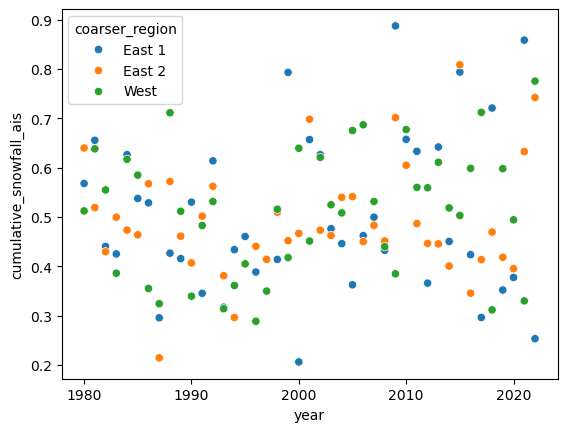

In [43]:
sns.scatterplot(data=averages, x='year', y='cumulative_snowfall_ais', hue='coarser_region')

## Multi-Characteristic Variability

In [70]:
covariates.columns

Index(['max_IWV_ais', 'max_south_extent', 'cumulative_landfalling_area',
       'avg_landfalling_minomega', 'max_landfalling_v850hPa',
       'max_ocean_SLP_gradient'],
      dtype='object')

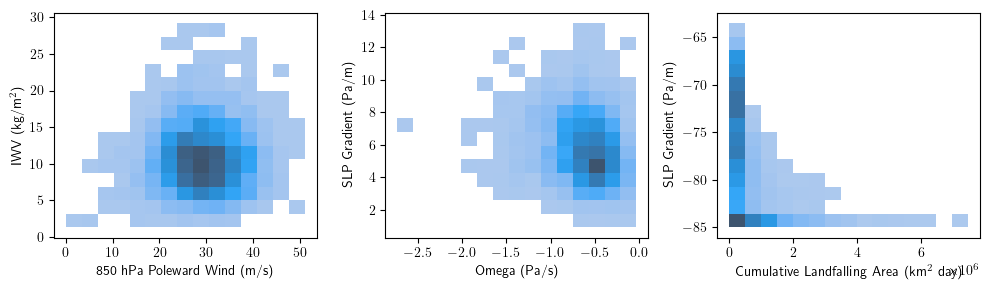

In [172]:
fig, axes = plt.subplots(ncols=3, figsize=(10, 3))

sns.histplot(data=covariates, x='max_landfalling_v850hPa', y='max_IWV_ais', bins=15, ax=axes[0])
axes[0].set_xlabel('850 hPa Poleward Wind (m/s)')
axes[0].set_ylabel('IWV (kg/m$^{2}$)')
sns.histplot(data=covariates, x='avg_landfalling_minomega', y='max_ocean_SLP_gradient', bins=15, ax=axes[1])
axes[1].set_xlabel('Omega (Pa/s)')
axes[1].set_ylabel('SLP Gradient (Pa/m)')
sns.histplot(data=covariates, x='cumulative_landfalling_area', y='max_south_extent', bins=15, ax=axes[2])
axes[2].set_xlabel('Cumulative Landfalling Area (km$^{2}$ day)')
axes[2].set_ylabel('SLP Gradient (Pa/m)')
plt.tight_layout()
plt.savefig('plots/bivariate_flavors.png')

## Multi-variable Plots

In [25]:
from scipy.stats import binned_statistic_2d
import numpy as np
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [113]:
def add_joint_plot(ax, x, y, z, cmap, bins = 15, title="", xlabel="", ylabel=""):
    
    divider = make_axes_locatable(ax)
    
    ax_top = divider.append_axes("top", size="20%", pad=0.1, sharex=ax)
    ax_right = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)
    ax_cbar = divider.append_axes("top", size="5%", pad=0.3)

    stat, x_edge, y_edge, _ = binned_statistic_2d(
            x, y, values=z, statistic='mean', bins=bins)
    mappable = ax.imshow(
        stat.T,
        origin='lower',
        extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
        cmap=cmap,
        aspect='auto'
    )
    sns.histplot(x=x, ax=ax_top, bins=bins, stat='count', color='gray', alpha=0.6, element="bars")
    sns.histplot(y=y, ax=ax_right, bins=bins, stat='count', color='gray', alpha=0.6, element="bars")

    ax_top.tick_params(axis="x", labelbottom=False)
    #ax_top.tick_params(axis="y", labelleft=False, left=False)
    ax_right.tick_params(axis="y", labelleft=False)
    #ax_right.tick_params(axis="x", labelbottom=False, bottom=False)
    ax_top.set_xlabel("")
    ax_top.set_ylabel("")
    ax_right.set_xlabel("")
    ax_right.set_ylabel("")

    plt.colorbar(mappable, ax_cbar, orientation='horizontal')

    ax_top.set_title(title, fontsize=16, pad=40)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)


In [114]:
subcat.max_landfalling_v850hPa.mean()

np.float64(29.3912108060584)

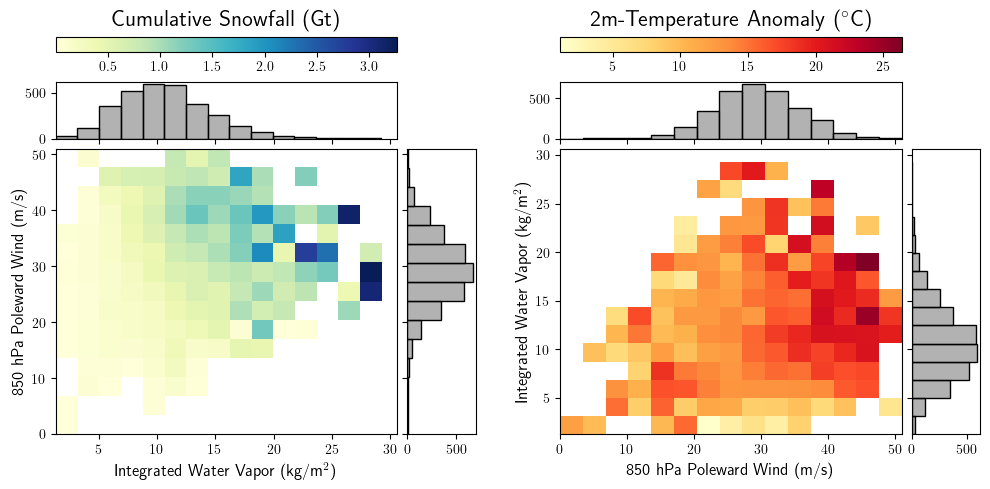

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

add_joint_plot(
    ax1,
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Cumulative Snowfall (Gt)',
    ylabel='850 hPa Poleward Wind (m/s)',
    xlabel='Integrated Water Vapor (kg/m$^{2}$)'
)

add_joint_plot(
    ax2, subcat.max_landfalling_v850hPa.to_numpy().astype(float),
    subcat.max_IWV_ais.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='2m-Temperature Anomaly ($^\\circ$C)',
    xlabel='850 hPa Poleward Wind (m/s)',
    ylabel='Integrated Water Vapor (kg/m$^{2}$)'
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.savefig('plots/outcome_IWV_wind.png')

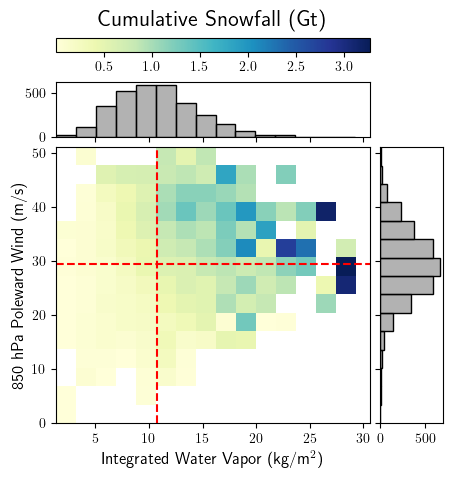

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

im = add_joint_plot(
    ax,
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Cumulative Snowfall (Gt)',
    ylabel='850 hPa Poleward Wind (m/s)',
    xlabel='Integrated Water Vapor (kg/m$^{2}$)'
)
ax.axhline(y=subcat.max_landfalling_v850hPa.mean(), color='r', linestyle='--')
ax.axvline(x=subcat.max_IWV_ais.mean(), color='r', linestyle='--')

plt.savefig('plots/AGU_outcome_IWV_wind.png', dpi=300)

In [174]:
subcat.columns

Index(['data_array', 'start_date', 'end_date', 'max_IWV_ais',
       'max_ocean_SLP_gradient', 'coarser_region', 'duration',
       'max_south_extent', 'cumulative_landfalling_area',
       'avg_landfalling_minomega', 'max_landfalling_v850hPa', 'max_vIVT_ais',
       'avg_vIVT_ais', 'max_T2M_anomaly_ais', 'cumulative_rainfall_ais',
       'cumulative_snowfall_ais'],
      dtype='object')

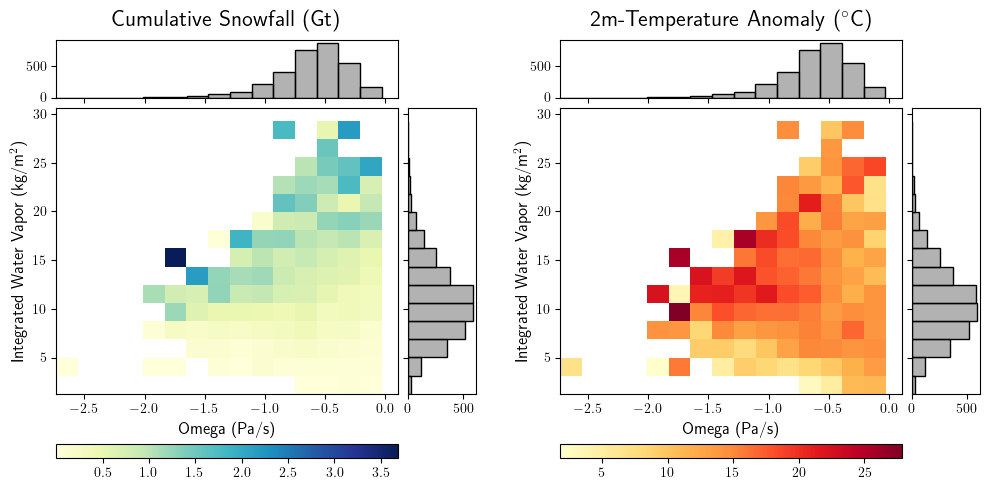

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

add_joint_plot(
    ax1, subcat.avg_landfalling_minomega.to_numpy().astype(float),
    subcat.max_IWV_ais.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Cumulative Snowfall (Gt)',
    xlabel='Omega (Pa/s)',
    ylabel='Integrated Water Vapor (kg/m$^{2}$)'
)

add_joint_plot(
    ax2, subcat.avg_landfalling_minomega.to_numpy().astype(float),
    subcat.max_IWV_ais.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='2m-Temperature Anomaly ($^\\circ$C)',
    xlabel='Omega (Pa/s)',
    ylabel='Integrated Water Vapor (kg/m$^{2}$)'
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.savefig('plots/outcome_omega_iwv.png')

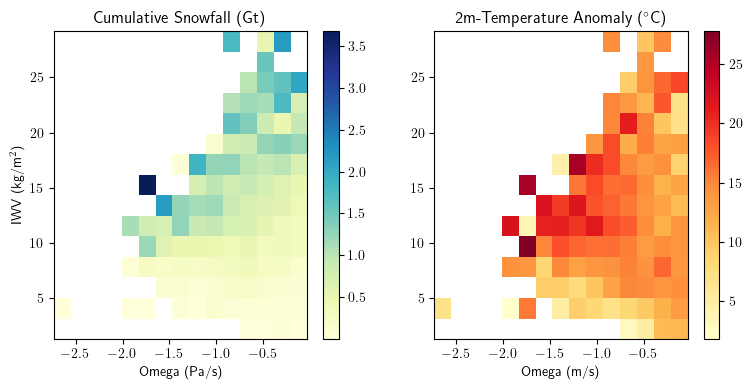

In [55]:
stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.avg_landfalling_minomega.to_numpy().astype(float), 
    subcat.max_IWV_ais.to_numpy().astype(float), 
    values=subcat.cumulative_snowfall_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

im1 = axs[0].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlGnBu',
    aspect='auto'  # Ensures the plot fills the space
)
axs[0].set_title('Cumulative Snowfall (Gt)')
axs[0].set_xlabel('Omega (Pa/s)')
axs[0].set_ylabel('IWV (kg/m$^{2}$)')

cbar1 = plt.colorbar(im1, ax=axs[0])

stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.avg_landfalling_minomega.to_numpy().astype(float), 
    subcat.max_IWV_ais.to_numpy().astype(float), 
    values=subcat.max_T2M_anomaly_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

im2 = axs[1].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlOrRd',
    aspect='auto'
)
axs[1].set_title('2m-Temperature Anomaly ($^\\circ$C)')
axs[1].set_xlabel('Omega (m/s)')
#axs[1].set_ylabel('IWV (kg/m$^{2}$)')

cbar2 = plt.colorbar(im2, ax=axs[1])

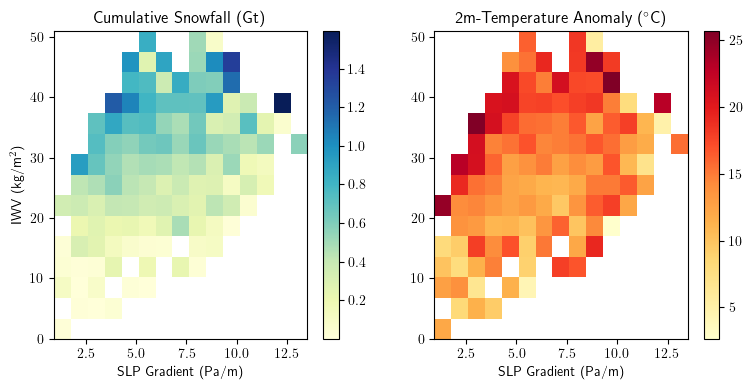

In [65]:
stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.max_ocean_SLP_gradient.to_numpy().astype(float), 
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    values=subcat.cumulative_snowfall_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

im1 = axs[0].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlGnBu',
    aspect='auto'  # Ensures the plot fills the space
)
axs[0].set_title('Cumulative Snowfall (Gt)')
axs[0].set_xlabel('SLP Gradient (Pa/m)')
axs[0].set_ylabel('IWV (kg/m$^{2}$)')

cbar1 = plt.colorbar(im1, ax=axs[0])

stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.max_ocean_SLP_gradient.to_numpy().astype(float), 
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    values=subcat.max_T2M_anomaly_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

im2 = axs[1].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlOrRd',
    aspect='auto'
)
axs[1].set_title('2m-Temperature Anomaly ($^\\circ$C)')
axs[1].set_xlabel('SLP Gradient (Pa/m)')
#axs[1].set_ylabel('IWV (kg/m$^{2}$)')

cbar2 = plt.colorbar(im2, ax=axs[1])

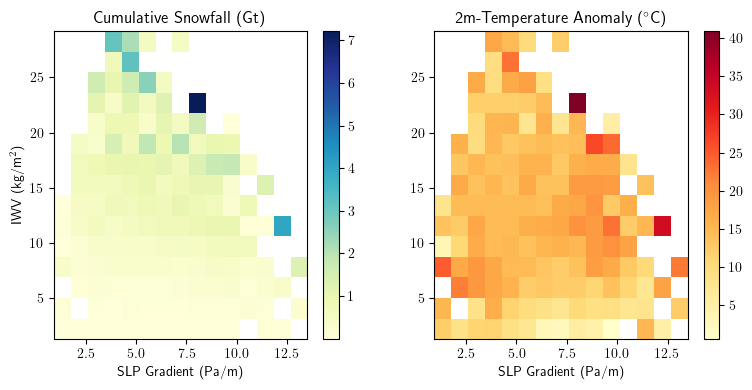

In [66]:
stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.max_ocean_SLP_gradient.to_numpy().astype(float), 
    subcat.max_IWV_ais.to_numpy().astype(float), 
    values=subcat.cumulative_snowfall_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

im1 = axs[0].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlGnBu',
    aspect='auto'  # Ensures the plot fills the space
)
axs[0].set_title('Cumulative Snowfall (Gt)')
axs[0].set_xlabel('SLP Gradient (Pa/m)')
axs[0].set_ylabel('IWV (kg/m$^{2}$)')

cbar1 = plt.colorbar(im1, ax=axs[0])

stat, x_edge, y_edge, binnumber = binned_statistic_2d(
    subcat.max_ocean_SLP_gradient.to_numpy().astype(float), 
    subcat.max_IWV_ais.to_numpy().astype(float), 
    values=subcat.max_T2M_anomaly_ais.to_numpy().astype(float), 
    statistic='mean', bins=15
)

im2 = axs[1].imshow(
    stat.T,
    origin='lower',
    extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
    cmap='YlOrRd',
    aspect='auto'
)
axs[1].set_title('2m-Temperature Anomaly ($^\\circ$C)')
axs[1].set_xlabel('SLP Gradient (Pa/m)')
#axs[1].set_ylabel('IWV (kg/m$^{2}$)')

cbar2 = plt.colorbar(im2, ax=axs[1])

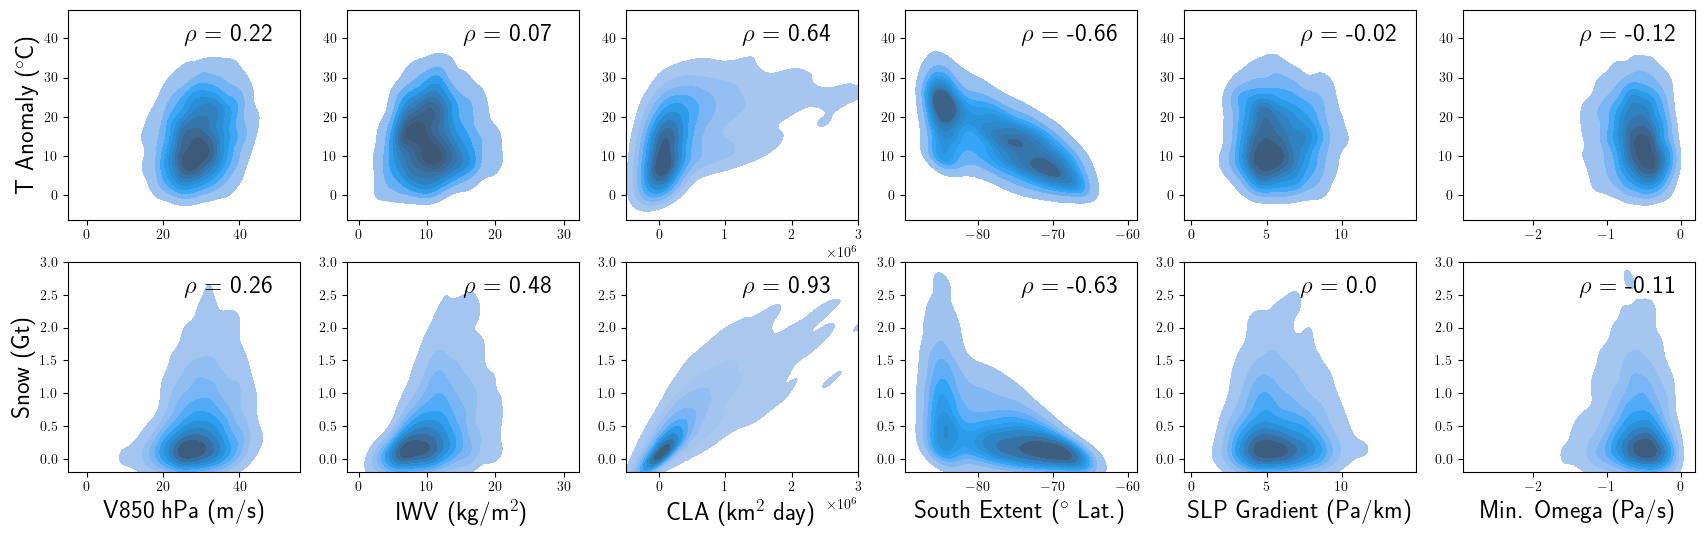

In [13]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=6)
fig.set_size_inches(21, 6)

catalog =subcat

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.avg_landfalling_minomega, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="avg_landfalling_minomega", y=impact1, fill=True, ax=axs[0,5])
axs[0,5].set_xlabel('')
axs[0,5].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,5].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (Pa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.avg_landfalling_minomega, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="avg_landfalling_minomega", y=impact2, fill=True, ax=axs[1,5])
axs[1,5].set_xlabel('Min. Omega (Pa/s)', fontsize=18)
axs[1,5].set_ylabel('')
axs[1,5].set_ylim(-0.2, 3)
axs[1,5].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18)

plt.savefig('plots/univariate_associations.png', dpi=300)

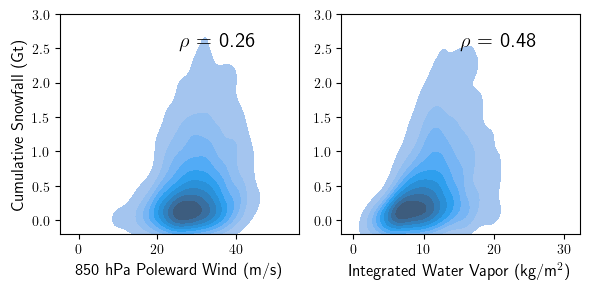

In [47]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6,3))

impact1 = "cumulative_snowfall_ais"

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0])
axs[0].set_xlabel('')
axs[0].set_ylabel('Cumulative Snowfall (Gt)', fontsize=12)
axs[0].set_ylim(-0.2, 3)
axs[0].set_xlabel('850 hPa Poleward Wind (m/s)', fontsize=12)
axs[0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=15);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[1])
axs[1].set_xlabel('')
axs[1].set_ylabel('')
axs[1].set_ylim(-0.2, 3)
axs[1].set_xlabel('Integrated Water Vapor (kg/m$^{2}$)', fontsize=12)
axs[1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=15);

plt.tight_layout()

plt.savefig('plots/univariate_associations_AGU.png', dpi=300)

## PCA

In [115]:
x_vars = ['max_IWV_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'cumulative_landfalling_area', 'max_south_extent']
snow_var = 'cumulative_snowfall_ais'
rain_var = 'cumulative_rainfall_ais'
temp_var = 'max_T2m_ais'

X = subcat[x_vars]
y = subcat[snow_var]
x_and_y = X.copy()
x_and_y['snow'] = y

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [116]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_and_y)

In [117]:
pca = PCA(n_components=7)
pca.fit(X_scaled)

PCA(n_components=7)

In [118]:
pca.explained_variance_ratio_

array([0.36755697, 0.23577117, 0.12473063, 0.11384325, 0.08736799,
       0.05676956, 0.01396043])

In [119]:
pca.components_

array([[ 0.3479767 , -0.07108495,  0.13883112,  0.03839761,  0.55999767,
        -0.44685667,  0.58295146],
       [-0.21076917,  0.60342232,  0.5588664 , -0.47388555,  0.10305227,
         0.16707573,  0.12658841],
       [-0.59726893,  0.32954667,  0.0378974 ,  0.60920535,  0.13338268,
        -0.37389469, -0.06718091],
       [ 0.54297028,  0.2289915 ,  0.40654016,  0.60138716, -0.11279423,
         0.32835349, -0.07256858],
       [-0.11988828, -0.54133243,  0.69388791, -0.038414  , -0.25656166,
        -0.33877928, -0.17039556],
       [-0.38085696, -0.4203977 ,  0.13596858,  0.16888632,  0.4208115 ,
         0.6378888 ,  0.21729992],
       [-0.15335074,  0.00391047, -0.04141572,  0.10565138, -0.63432102,
         0.05583939,  0.74706733]])

In [26]:
X = train_data[x_vars]
y = train_data[temp_var]
x_and_y = X.copy()
x_and_y['temp'] = y

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_and_y)

pca = PCA(n_components=7)
pca.fit(X_scaled)

PCA(n_components=7)

In [27]:
pca.explained_variance_ratio_

array([0.33540769, 0.23803375, 0.15724872, 0.10006506, 0.08289469,
       0.05602644, 0.03032364])

In [28]:
pca.components_

array([[ 0.52851937, -0.28490025,  0.01602342,  0.00131437,  0.40916942,
        -0.40414989,  0.55541326],
       [ 0.00524552,  0.51896735,  0.61266792,  0.5082903 ,  0.30121738,
        -0.07193165, -0.03191076],
       [ 0.41554875, -0.05063129,  0.05326411,  0.35787731, -0.45015337,
         0.60733896,  0.34977679],
       [-0.22584236, -0.3923158 , -0.33446626,  0.7769226 , -0.02395811,
        -0.24448833, -0.13877538],
       [-0.18488772, -0.55165384,  0.70255541, -0.09873695, -0.35268822,
        -0.18377038, -0.00096988],
       [-0.03747648, -0.4308163 ,  0.12135929, -0.01258256,  0.63338535,
         0.5872983 , -0.22805731],
       [-0.67923947,  0.05572144, -0.03693698, -0.00685891,  0.11432605,
         0.15544358,  0.70490022]])